Equilibrios aproximados en [0,n]: [698.8781340240942]


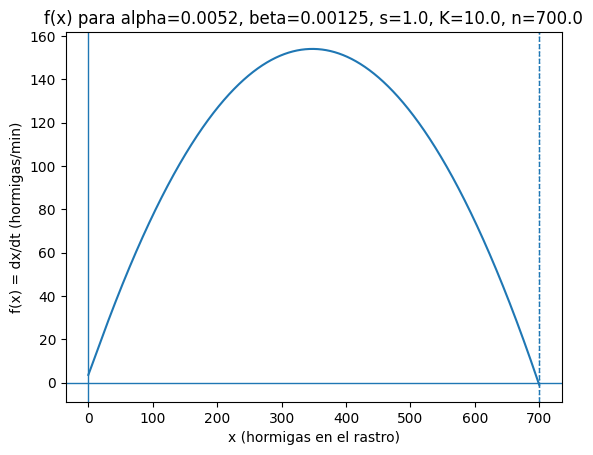

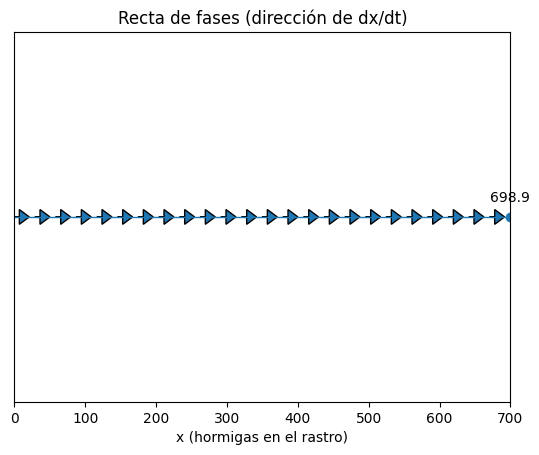

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Parámetros del modelo 
alpha = 0.0052      # 1/min
beta  = 0.00125     # 1/(ant*min)
s     = 1.0         # ant/min
K     = 10.0        # ants

# Elige el tamaño de colonia
n = 700.0           # ants (prueba también n=500, n=628, n=800, etc.)

def f(x):
    """dx/dt = f(x)"""
    return (alpha + beta*x)*(n - x) - (s*x)/(x + K)

# --- Encontrar equilibrios (raíces de f en [0,n]) ---
xs = np.linspace(0.0, n, 4000)
fs = f(xs)

roots = []
for i in range(len(xs) - 1):
    if fs[i] == 0:
        roots.append(xs[i])
    elif fs[i] * fs[i+1] < 0:
        # cambio de signo -> hay raíz en (xs[i], xs[i+1])
        r = brentq(f, xs[i], xs[i+1])
        # evita duplicados numéricos
        if not roots or abs(r - roots[-1]) > 1e-3:
            roots.append(r)

print("Equilibrios aproximados en [0,n]:", roots)

# --- Figura 1: f(x) vs x (muy útil para recta de fases) ---
plt.figure()
plt.plot(xs, fs)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.axvline(n, linestyle="--", linewidth=1)

for r in roots:
    plt.axvline(r, linestyle=":", linewidth=1)

plt.xlabel("x (hormigas en el rastro)")
plt.ylabel("f(x) = dx/dt (hormigas/min)")
plt.title(f"f(x) para alpha={alpha}, beta={beta}, s={s}, K={K}, n={n}")
plt.show()

# --- Figura 2: recta de fases (flechas en el eje x) ---
plt.figure()
plt.axhline(0, linewidth=1)
plt.xlim(0, n)
plt.ylim(-1, 1)
plt.yticks([])

# puntos de equilibrio
for r in roots:
    plt.plot([r], [0], marker="o")
    plt.text(r, 0.08, f"{r:.1f}", ha="center")

# flechas según el signo de f
# (dibujamos flechas en subintervalos evitando puntos cerca de raíces)
test_points = np.linspace(0, n, 25)
for x0 in test_points:
    # evita dibujar justo encima de un equilibrio
    if any(abs(x0 - r) < 0.02*n for r in roots):
        continue
    direction = 1 if f(x0) > 0 else -1
    dx = 0.03*n * direction
    plt.arrow(x0, 0, dx, 0, head_width=0.08, head_length=0.02*n, length_includes_head=True)

plt.xlabel("x (hormigas en el rastro)")
plt.title("Recta de fases (dirección de dx/dt)")
plt.show()


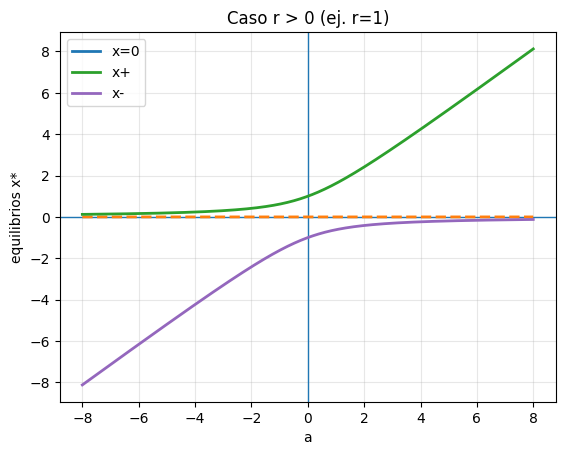

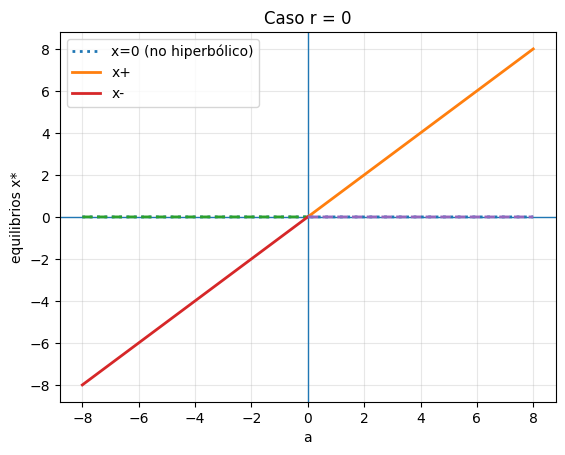

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14316\1188403003.py:11: RuntimeWarning: invalid value encountered in sqrt
  sqrt_disc = np.where(disc >= 0, np.sqrt(disc), np.nan)


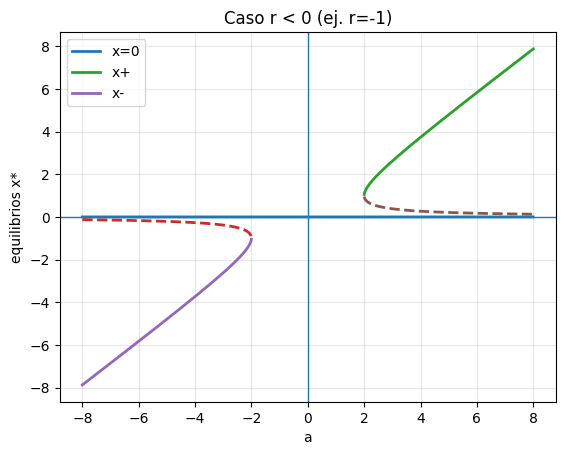

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def equilibria_branches(a, r):
    """
    Returns x0, xplus, xminus arrays (with NaN where they don't exist).
    """
    x0 = np.zeros_like(a, dtype=float)

    disc = a*a + 4*r
    sqrt_disc = np.where(disc >= 0, np.sqrt(disc), np.nan)

    xplus  = 0.5*(a + sqrt_disc)
    xminus = 0.5*(a - sqrt_disc)
    return x0, xplus, xminus, disc

def stability_fx(x, a, r):
    """
    f(x) = r x + a x^2 - x^3
    f_x  = r + 2 a x - 3 x^2
    Stable iff f_x < 0 (1D flow).
    """
    return r + 2*a*x - 3*x*x

def plot_branch(ax, a, x, stable_mask, label=None):
    """
    Plot stable part solid and unstable part dashed.
    """
    # stable
    xs = np.where(stable_mask, x, np.nan)
    ax.plot(a, xs, lw=2, label=label)

    # unstable
    xu = np.where(~stable_mask, x, np.nan)
    ax.plot(a, xu, lw=2, ls="--")

def plot_bifurcation_for_r(r, a_min=-6, a_max=6, n=4000, title=None):
    a = np.linspace(a_min, a_max, n)
    x0, xplus, xminus, disc = equilibria_branches(a, r)

    # Stability masks (ignore NaNs automatically)
    fx0    = stability_fx(x0, a, r)
    fxplus = stability_fx(xplus, a, r)
    fxminus= stability_fx(xminus, a, r)

    st0    = fx0 < 0
    stplus = fxplus < 0
    stminus= fxminus < 0

    fig, ax = plt.subplots()
    ax.axhline(0, lw=1)
    ax.axvline(0, lw=1)

    # Branch x=0:
    if r == 0:
        # non-hyperbolic: show as dotted (neither stable nor unstable in the usual linear sense)
        ax.plot(a, x0, lw=2, ls=":", label="x=0 (no hiperbólico)")
    else:
        plot_branch(ax, a, x0, st0, label="x=0")

    # Branches x± exist only where disc>=0
    exists = disc >= 0
    # plot xplus
    plot_branch(ax, a, np.where(exists, xplus, np.nan), np.where(exists, stplus, False), label="x+")
    # plot xminus
    plot_branch(ax, a, np.where(exists, xminus, np.nan), np.where(exists, stminus, False), label="x-")

    ax.set_xlabel("a")
    ax.set_ylabel("equilibrios x*")
    ax.set_title(title if title is not None else f"Diagrama de bifurcación vs a (r={r})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

# --- Graficar los tres casos ---
plot_bifurcation_for_r(r=1.0,  a_min=-8, a_max=8, title="Caso r > 0 (ej. r=1)")
plot_bifurcation_for_r(r=0.0,  a_min=-8, a_max=8, title="Caso r = 0")
plot_bifurcation_for_r(r=-1.0, a_min=-8, a_max=8, title="Caso r < 0 (ej. r=-1)")